# 03 — Eigenvalues, Eigenvectors, SVD & PCA ⭐

**The single highest-interview-yield notebook in this chapter.** If you only have time to deeply master one linear algebra topic, make it this one.

**Book reference:** *Mathematics for Machine Learning* (Deisenroth, Faisal, Ong) — §4.1–4.6, pp.99–134 (Determinant and Trace, Eigenvalues and Eigenvectors, Cholesky Decomposition, Eigendecomposition and Diagonalization, Singular Value Decomposition, Matrix Approximation)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

## Eigenvectors: the directions a matrix doesn't rotate

For a matrix `A`, an eigenvector `v` and its eigenvalue `λ` satisfy `Av = λv` — applying `A` to `v` doesn't change its direction, only scales it by `λ`.

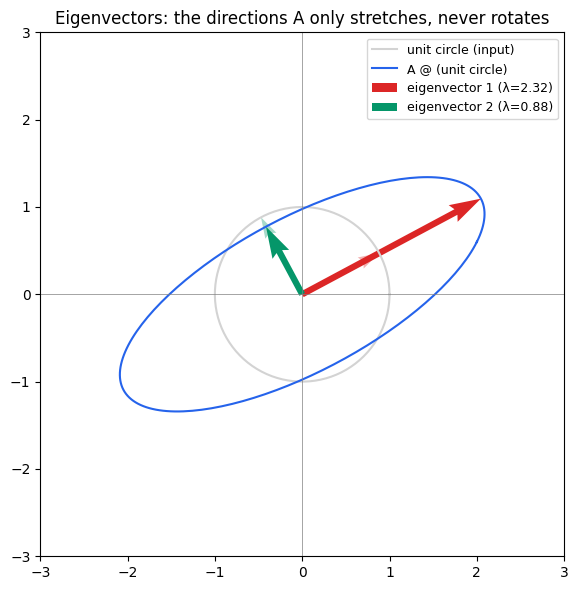

Eigenvalues: [2.32111026 0.87888974]
Eigenvectors (columns):
 [[ 0.8816746  -0.47185793]
 [ 0.47185793  0.8816746 ]]


In [2]:
def visualize_eigenvectors(A: np.ndarray, savepath: Path = None):
    """Show a unit circle transformed by A into an ellipse, with the
    eigenvectors overlaid — they're exactly the axes of that ellipse."""
    theta = np.linspace(0, 2 * np.pi, 200)
    circle = np.stack([np.cos(theta), np.sin(theta)])
    transformed = A @ circle

    eigvals, eigvecs = np.linalg.eig(A)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(circle[0], circle[1], color="lightgray", label="unit circle (input)")
    ax.plot(transformed[0], transformed[1], color="#2563eb", label="A @ (unit circle)")

    colors = ["#dc2626", "#059669"]
    for i in range(2):
        v = eigvecs[:, i].real
        lam = eigvals[i].real
        ax.quiver(0, 0, *(v * lam), angles="xy", scale_units="xy", scale=1,
                   color=colors[i], width=0.012, label=f"eigenvector {i+1} (λ={lam:.2f})")
        ax.quiver(0, 0, *v, angles="xy", scale_units="xy", scale=1,
                   color=colors[i], alpha=0.35, width=0.008)

    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    lim = max(3, np.abs(transformed).max() * 1.2)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.legend(fontsize=9)
    ax.set_title("Eigenvectors: the directions A only stretches, never rotates")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()
    return eigvals, eigvecs

A = np.array([[2.0, 0.6],
              [0.6, 1.2]])
eigvals, eigvecs = visualize_eigenvectors(A, FIG_DIR / "eigenvectors.png")
print("Eigenvalues:", eigvals)
print("Eigenvectors (columns):\n", eigvecs)

The unit circle (gray) gets transformed by `A` into an ellipse (blue). The eigenvectors (red, green) are exactly the **axes of that ellipse** — every other direction on the circle gets rotated *and* stretched, but these two directions only stretch, by a factor of their eigenvalue.

**Symmetric matrices** (like covariance matrices — this is why they matter so much in ML) have a special guarantee: their eigenvalues are always real, and their eigenvectors are always orthogonal to each other. That guarantee is what makes PCA well-defined.

## PCA: this picture *is* the derivation

PCA answers: "what's the direction along which my data varies the most?" The answer is: **the eigenvector of the covariance matrix with the largest eigenvalue.**

Walking through why:
1. You want to find a direction `w` (with `‖w‖=1`) that maximizes the variance of the data projected onto it: `Var(Xw) = wᵀΣw`, where `Σ` is the covariance matrix.
2. Maximizing `wᵀΣw` subject to `‖w‖=1` is a constrained optimization problem. Using a Lagrange multiplier: maximize `wᵀΣw - λ(wᵀw - 1)`.
3. Taking the derivative w.r.t. `w` and setting it to zero gives `Σw = λw` — **that's exactly the eigenvector equation.**
4. So the variance-maximizing direction is the top eigenvector of `Σ`, and the variance captured along it is that eigenvector's eigenvalue.

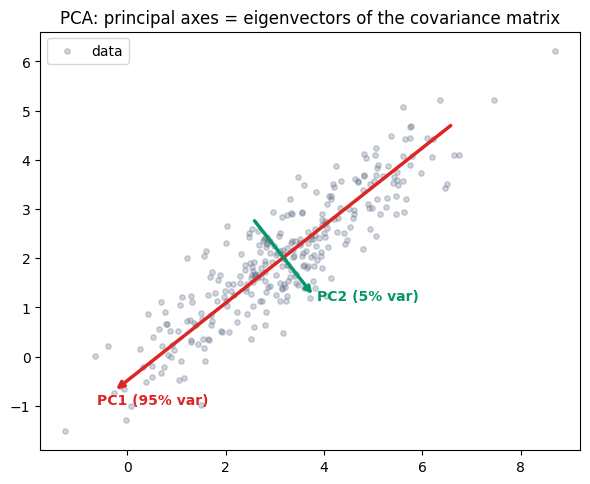

In [3]:
def pca_from_scratch(X, n_components):
    X_centered = X - X.mean(axis=0, keepdims=True)
    cov = (X_centered.T @ X_centered) / (X_centered.shape[0] - 1)
    eigvals, eigvecs = np.linalg.eigh(cov)           # symmetric -> eigh, not eig
    order = np.argsort(eigvals)[::-1]                # eigh returns ascending order
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    components = eigvecs[:, :n_components].T
    X_projected = X_centered @ components.T
    return X_projected, components, eigvals[:n_components]


def visualize_pca(savepath: Path = None, rng=None):
    rng = rng or np.random.default_rng(7)
    mean = [3, 2]
    cov_true = [[3.0, 2.2], [2.2, 2.0]]
    X = rng.multivariate_normal(mean, cov_true, size=300)

    _, components, explained_variance = pca_from_scratch(X, n_components=2)
    center = X.mean(axis=0)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(X[:, 0], X[:, 1], alpha=0.3, s=15, color="#64748b", label="data")

    colors = ["#dc2626", "#059669"]
    for i in range(2):
        direction = components[i]
        length = 2.2 * np.sqrt(explained_variance[i])
        ax.annotate("", xy=center + direction * length, xytext=center - direction * length,
                    arrowprops=dict(arrowstyle="->", color=colors[i], lw=2.5))
        pct = explained_variance[i] / explained_variance.sum() * 100
        ax.text(*(center + direction * length * 1.1), f"PC{i+1} ({pct:.0f}% var)",
                color=colors[i], fontsize=10, fontweight="bold")

    ax.set_aspect("equal")
    ax.set_title("PCA: principal axes = eigenvectors of the covariance matrix")
    ax.legend(loc="upper left")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_pca(FIG_DIR / "pca_2d.png")

In the figure, PC1 captures the direction of maximum spread; PC2 (orthogonal to PC1, guaranteed by the symmetric-matrix property above) captures what's left.

## SVD: the generalization that always exists

Eigendecomposition requires a square, diagonalizable matrix. **SVD works for any matrix** — including non-square ones — because it's built from the eigendecompositions of `AᵀA` and `AAᵀ`, which are always symmetric and positive semi-definite (hence always diagonalizable, by the guarantee above).

`A = UΣVᵀ`, where `U` and `V` are orthogonal matrices (their columns are the eigenvectors of `AAᵀ` and `AᵀA` respectively) and `Σ` is diagonal, holding the **singular values** (square roots of the eigenvalues of `AᵀA`).

**Relationship to eigendecomposition:** for a symmetric positive semi-definite matrix, SVD and eigendecomposition coincide exactly (`U = V`, singular values = eigenvalues). This is why, for the covariance matrix in PCA, you'll see both `eigh(cov)` and `svd(X_centered)` used interchangeably in practice — they give the same answer, and the SVD route is often more numerically stable since it avoids explicitly forming `Σ = XᵀX`.

## Low-rank approximation — why this matters practically

The Eckart–Young theorem says the best rank-k approximation of a matrix (in a least-squares sense) is obtained by keeping only the top k singular values/vectors and zeroing out the rest. This is the mathematical basis for compression, denoising, and dimensionality reduction across ML.

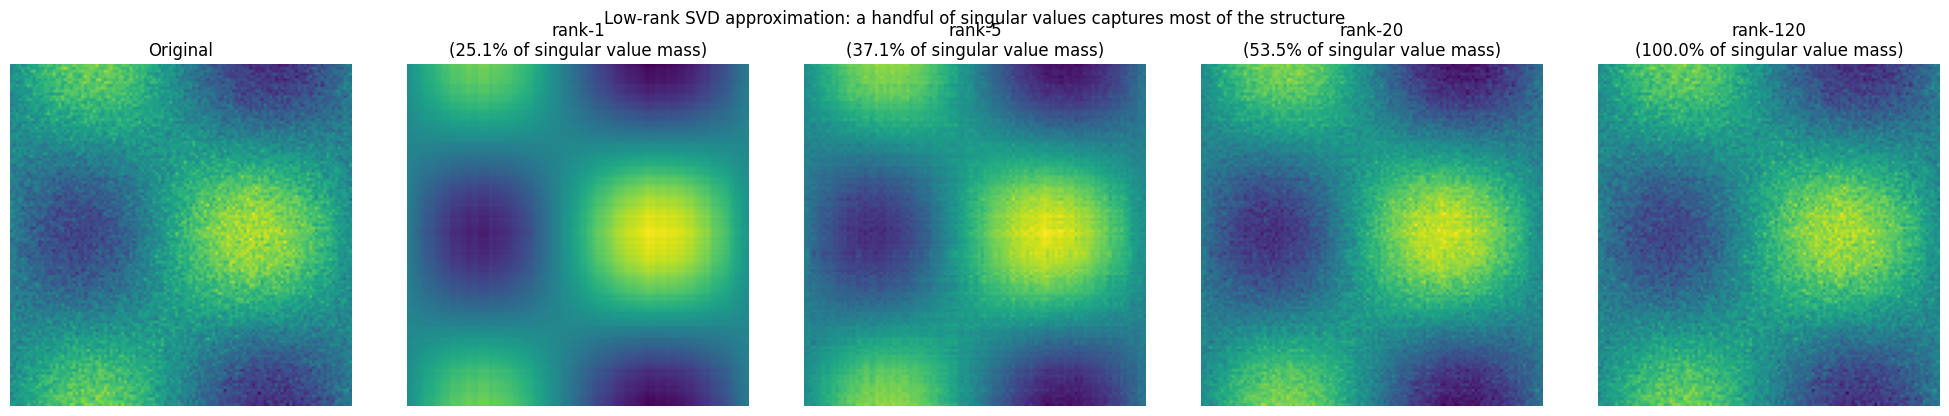

In [4]:
def make_synthetic_image(size: int = 120, rng=None) -> np.ndarray:
    """A synthetic 'image' with strong low-frequency structure + a little
    noise, so a handful of singular values capture most of it (like most
    real images/data do) while exact reconstruction needs the noisy tail.
    No external image download needed -> fully reproducible offline."""
    rng = rng or np.random.default_rng(42)
    x = np.linspace(-3, 3, size)
    xx, yy = np.meshgrid(x, x)
    img = (np.sin(xx) * np.cos(yy)
           + 0.6 * np.exp(-(xx ** 2 + yy ** 2) / 3)
           + 0.15 * rng.normal(size=(size, size)))
    return img


def low_rank_approx_svd(A, k):
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]


def visualize_svd_compression(savepath: Path = None):
    img = make_synthetic_image()
    U, S, Vt = np.linalg.svd(img, full_matrices=False)

    ks = [1, 5, 20, min(len(S), 120)]
    fig, axes = plt.subplots(1, len(ks) + 1, figsize=(4 * (len(ks) + 1), 4.2))

    axes[0].imshow(img, cmap="viridis"); axes[0].set_title("Original"); axes[0].axis("off")

    for ax, k in zip(axes[1:], ks):
        approx = low_rank_approx_svd(img, k)
        variance_captured = S[:k].sum() / S.sum() * 100
        ax.imshow(approx, cmap="viridis")
        ax.set_title(f"rank-{k}\n({variance_captured:.1f}% of singular value mass)")
        ax.axis("off")

    fig.suptitle("Low-rank SVD approximation: a handful of singular values captures most of the structure")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()
    return S

S = visualize_svd_compression(FIG_DIR / "svd_compression.png")

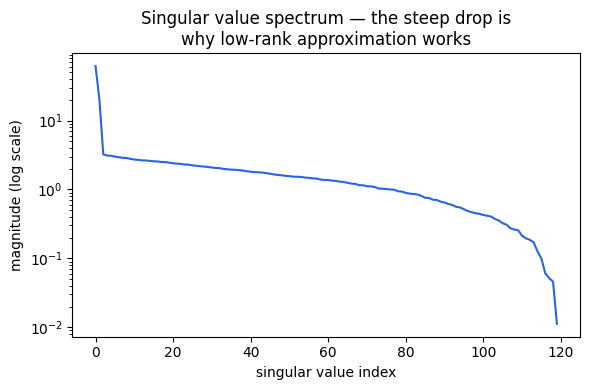

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(S, color="#2563eb")
ax.set_yscale("log")
ax.set_xlabel("singular value index")
ax.set_ylabel("magnitude (log scale)")
ax.set_title("Singular value spectrum — the steep drop is\nwhy low-rank approximation works")
fig.tight_layout()
fig.savefig(FIG_DIR / "svd_spectrum.png", dpi=140)
plt.show()

Even a synthetic image with real structure is captured almost entirely by the first ~20 singular values out of 120 — the rest is mostly the added noise. This is *exactly* the intuition behind why PCA-based dimensionality reduction works on real data: most of the "signal" concentrates in a small number of directions, and you can discard the rest with minimal information loss.

That steep drop-off in the spectrum is the visual answer to "how many components/singular values do I actually need?" — a question that comes up constantly in both PCA and low-rank model compression (e.g., LoRA fine-tuning deliberately exploits this: full weight updates during fine-tuning are empirically low-rank, so constraining the update to rank `r` loses little while cutting trainable parameters enormously).

## Self-check before moving on

- [ ] I can state `Av = λv` and explain what it means geometrically
- [ ] I can derive PCA from "maximize projected variance" to "eigenvectors of the covariance matrix," writing out each step
- [ ] I can explain why SVD always exists but eigendecomposition doesn't, and when the two coincide
- [ ] I can explain what a low-rank approximation is and why the singular value spectrum tells you how many components you need
- [ ] I can connect this to at least one real ML technique beyond PCA (e.g., LoRA, recommender systems via matrix factorization)

This closes out the Linear Algebra subchapter. Next up: **Calculus** (differentiation, gradients, backprop math) — building on the vector/matrix machinery from this chapter.